In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from alpha.analysist import datastore

In [3]:
ds = datastore.DataStore(live=False)

In [4]:
day, next_day="2026-09-02", "2026-09-03"
symbols = ds.sql("SELECT DISTINCT symbol FROM tick WHERE dt>=? AND dt<? ORDER BY symbol", [day, next_day])

In [5]:
symbols_lst = [item for tup in symbols[0] for item in tup]

In [6]:
tick = ds.ticks(symbol=symbols_lst[1], start=day, end=day)

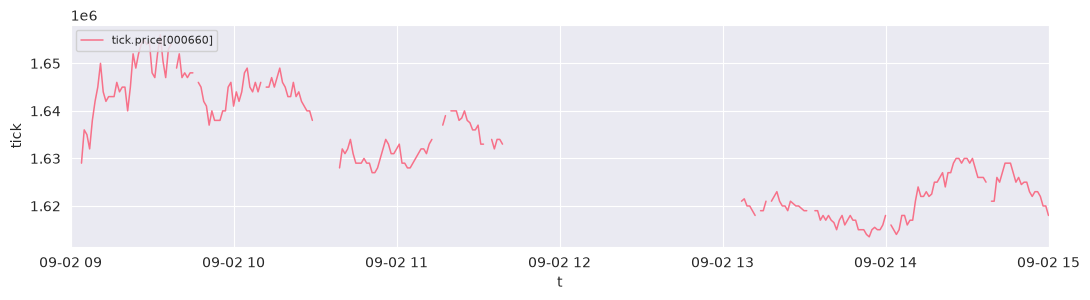

(<Figure size 1100x310 with 1 Axes>, [<Axes: xlabel='t', ylabel='tick'>])

In [7]:
tick.time_frame(mode="min", start=day+" 09:00", end=day+" 15:00").plot(columns=["price"])

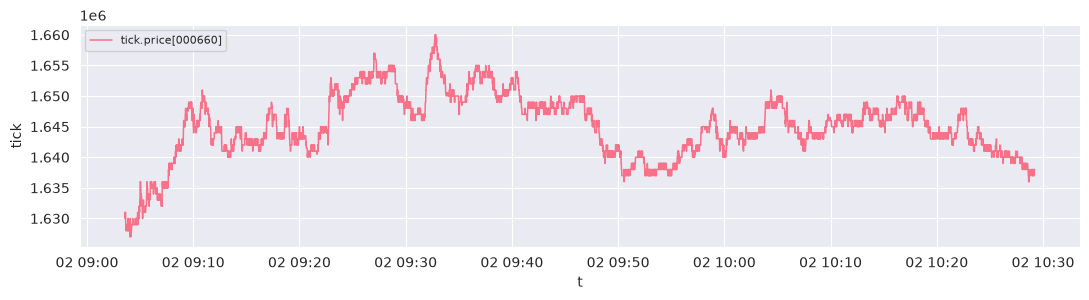

(<Figure size 1100x310 with 1 Axes>, [<Axes: xlabel='t', ylabel='tick'>])

In [13]:
tick.split_by_gap("5s").segments[0].resample_frame(rule="1s").plot(columns=["price"])

In [10]:
ind = ds.indicators(symbol=symbols_lst[1], label="OFI_KF", start=day, end=day)

In [26]:
df = tick.add(ind).join(0).where(lambda df: df["line"] == "level").split_by_gap("1min").segments[2].return_ic(x='value', y='price')
df.assign(expected_return = df.IC * df.sigma_bp)

,h,IC,t,p,n,sigma_bp,expected_return
0,1,0.0293,2.59,0.0097,7768,3.79,0.111047
1,2,0.0545,3.40,0.0007,3884,4.00,0.218000
2,3,0.0750,3.83,0.0001,2589,4.21,0.315750
3,5,0.0967,3.83,0.0001,1553,4.57,0.441919
4,10,0.1194,3.35,0.0009,776,5.32,0.635208
5,20,0.1438,2.86,0.0045,388,6.19,0.890122
6,30,0.1574,2.55,0.0114,258,7.55,1.188370
7,60,0.1519,1.73,0.0857,129,9.56,1.452164
8,120,0.1630,1.30,0.1981,64,13.74,2.239620


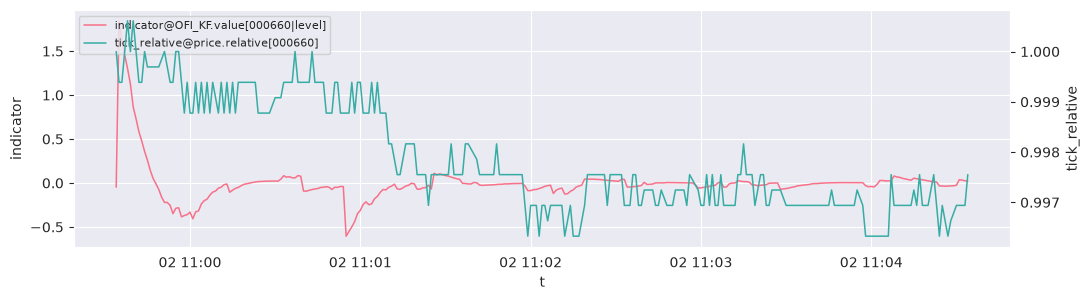

(<Figure size 1100x310 with 2 Axes>, [<Axes: xlabel='t', ylabel='indicator'>])

In [74]:
from datetime import datetime, timedelta
t = ind.where(lambda df: (df['line'] == 'level')&(df['value'] >=2)).split_by_gap('1min').segments[0].base.times[0]
t5 = t+timedelta(minutes=5)
r_tick = tick.resample_frame('s').tslice(t.strftime('%Y-%m-%d %H:%M:%S'), t5.strftime('%Y-%m-%d %H:%M:%S')).relative('price', replace=True)
ind.add(r_tick).tslice(t.strftime('%Y-%m-%d %H:%M:%S'), t5.strftime('%Y-%m-%d %H:%M:%S')).where(lambda df: (df['line'] == 'level')).plot(columns=['price'])

In [80]:
tick.resample_frame('s').tslice(t.strftime('%Y-%m-%d %H:%M:%S'), t5.strftime('%Y-%m-%d %H:%M:%S')).relative('price', replace=True).return_passage(y='relative', levels=[1.003, .997])

,t1.003,len1.003,max1.003,min1.003,t0.997,len0.997,max0.997,min0.997,n,first,last,max,min,imax,imin,mean,std
000660,NaN,263,1.000612,0.996328,97,98,1.000612,0.99694,263,1.0,0.997552,1.000612,0.996328,3,127,0.997843,0.001075


In [97]:
for i in range(tick.resample_frame('s').tslice(t.strftime('%Y-%m-%d %H:%M:%S'), t5.strftime('%Y-%m-%d %H:%M:%S')).split_by_gap('1s').segments_len):
    ti = tick.resample_frame('s').tslice(t.strftime('%Y-%m-%d %H:%M:%S'), t5.strftime('%Y-%m-%d %H:%M:%S')).split_by_gap('1s').segments[i].base.times[[0,0]]
    print(i, ti[0], ti[1])

0 2026-09-02 10:59:34 2026-09-02 10:59:34
1 2026-09-02 10:59:38 2026-09-02 10:59:38
2 2026-09-02 10:59:42 2026-09-02 10:59:42
3 2026-09-02 10:59:51 2026-09-02 10:59:51
4 2026-09-02 10:59:53 2026-09-02 10:59:53
5 2026-09-02 11:00:10 2026-09-02 11:00:10
6 2026-09-02 11:00:22 2026-09-02 11:00:22
7 2026-09-02 11:00:30 2026-09-02 11:00:30
8 2026-09-02 11:00:36 2026-09-02 11:00:36
9 2026-09-02 11:00:40 2026-09-02 11:00:40
10 2026-09-02 11:00:56 2026-09-02 11:00:56
11 2026-09-02 11:01:28 2026-09-02 11:01:28
12 2026-09-02 11:01:31 2026-09-02 11:01:31
13 2026-09-02 11:01:35 2026-09-02 11:01:35
14 2026-09-02 11:01:41 2026-09-02 11:01:41
15 2026-09-02 11:02:14 2026-09-02 11:02:14
16 2026-09-02 11:02:26 2026-09-02 11:02:26
17 2026-09-02 11:02:48 2026-09-02 11:02:48
18 2026-09-02 11:02:53 2026-09-02 11:02:53
19 2026-09-02 11:02:59 2026-09-02 11:02:59
20 2026-09-02 11:03:12 2026-09-02 11:03:12
21 2026-09-02 11:03:18 2026-09-02 11:03:18
22 2026-09-02 11:03:21 2026-09-02 11:03:21
23 2026-09-02 11:03:3